# Railway Passenger Forecasting in Jabodetabek Region

**Project type:** Time Series Analysis and Forecasting

## Project Overview

This project analyzes monthly railway passenger data in the Jabodetabek region from 2015 to 2019. It explores passenger trends and seasonal patterns, then compares forecasting models using 2019 as the test period.

The project is a reconstruction inspired by an earlier academic project and uses the dataset currently available for this portfolio.


### 1. Import Libraries and Load Dataset

Pandas is used to load and manipulate the dataset. The Excel file is imported into a DataFrame for further analysis.


In [2]:
import pandas as pd

file_path = "/content/railway_passenger_jabodetabek.xlsx"

raw = pd.read_excel(file_path, header=None)

raw.head(8)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Tahun,Jumlah Penumpang Kereta Api Jabodetabek (Ribu ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
2,2015,19244,17640,21290,21171,22177,22207,21171,22295,22021,22964,22355,22996
3,2016,22238,21229,23206,23149,24401,23821,21574,23923,23570,24533,24104,24841
4,2017,24185,21743,25775,25411,27385,24432,27016,27679,26158,28765,28246,29059
5,2018,28075,25362,29223,28942,28995,24833,29086,28098,27618,29317,28049,29201
6,2019,27768,25305,28366,28062,28369,25816,29714,27651,28293,29278,28563,28860


### 2. Data Inspection and Cleaning

The original spreadsheet contains a multi-row header. The data is inspected and cleaned by selecting the correct rows, assigning column names, and checking data types and missing values.


In [3]:
df = pd.read_excel(
    file_path,
    skiprows=2,
    header=None
)

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,2015,19244,17640,21290,21171,22177,22207,21171,22295,22021,22964,22355,22996
1,2016,22238,21229,23206,23149,24401,23821,21574,23923,23570,24533,24104,24841
2,2017,24185,21743,25775,25411,27385,24432,27016,27679,26158,28765,28246,29059
3,2018,28075,25362,29223,28942,28995,24833,29086,28098,27618,29317,28049,29201
4,2019,27768,25305,28366,28062,28369,25816,29714,27651,28293,29278,28563,28860


In [4]:
df.columns = [
    "Tahun",
    "Januari", "Februari", "Maret", "April",
    "Mei", "Juni", "Juli", "Agustus",
    "September", "Oktober", "November", "Desember"
]

df.head()

,Tahun,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,2015,19244,17640,21290,21171,22177,22207,21171,22295,22021,22964,22355,22996
1,2016,22238,21229,23206,23149,24401,23821,21574,23923,23570,24533,24104,24841
2,2017,24185,21743,25775,25411,27385,24432,27016,27679,26158,28765,28246,29059
3,2018,28075,25362,29223,28942,28995,24833,29086,28098,27618,29317,28049,29201
4,2019,27768,25305,28366,28062,28369,25816,29714,27651,28293,29278,28563,28860


In [5]:
# Pastikan tahun dan jumlah penumpang berupa angka
df["Tahun"] = df["Tahun"].astype(int)

bulan = [
    "Januari", "Februari", "Maret", "April",
    "Mei", "Juni", "Juli", "Agustus",
    "September", "Oktober", "November", "Desember"
]

df[bulan] = df[bulan].apply(pd.to_numeric)

print(df.dtypes)

Tahun        int64
Januari      int64
Februari     int64
Maret        int64
April        int64
Mei          int64
Juni         int64
Juli         int64
Agustus      int64
September    int64
Oktober      int64
November     int64
Desember     int64
dtype: object


In [6]:
print("Data kosong:")
print(df.isnull().sum())

print("Jumlah data:", df.shape)

Data kosong:
Tahun        0
Januari      0
Februari     0
Maret        0
April        0
Mei          0
Juni         0
Juli         0
Agustus      0
September    0
Oktober      0
November     0
Desember     0
dtype: int64
Jumlah data: (5, 13)


### 3. Reshape Data into Monthly Time Series

The dataset is transformed from a wide format, where months are separate columns, into a long format with one observation per month. A monthly date index is then created and the observations are sorted chronologically.


In [7]:
df_long = df.melt(
    id_vars="Tahun",
    value_vars=bulan,
    var_name="Bulan",
    value_name="Jumlah_Penumpang"
)

df_long.head()

,Tahun,Bulan,Jumlah_Penumpang
0,2015,Januari,19244
1,2016,Januari,22238
2,2017,Januari,24185
3,2018,Januari,28075
4,2019,Januari,27768


In [8]:
# Ubah nama bulan menjadi angka
month_map = {
    "Januari": 1,
    "Februari": 2,
    "Maret": 3,
    "April": 4,
    "Mei": 5,
    "Juni": 6,
    "Juli": 7,
    "Agustus": 8,
    "September": 9,
    "Oktober": 10,
    "November": 11,
    "Desember": 12
}

df_long["Bulan_Angka"] = df_long["Bulan"].map(month_map)

# Buat tanggal bulanan
df_long["Tanggal"] = pd.to_datetime(
    dict(
        year=df_long["Tahun"],
        month=df_long["Bulan_Angka"],
        day=1
    )
)

# Urutkan berdasarkan tanggal
df_long = df_long.sort_values("Tanggal").reset_index(drop=True)

df_long.head()

,Tahun,Bulan,Jumlah_Penumpang,Bulan_Angka,Tanggal
0,2015,Januari,19244,1,2015-01-01
1,2015,Februari,17640,2,2015-02-01
2,2015,Maret,21290,3,2015-03-01
3,2015,April,21171,4,2015-04-01
4,2015,Mei,22177,5,2015-05-01


In [9]:
print("Jumlah data:", len(df_long))
print("Tanggal awal:", df_long["Tanggal"].min())
print("Tanggal akhir:", df_long["Tanggal"].max())

df_long.tail()

Jumlah data: 60
Tanggal awal: 2015-01-01 00:00:00
Tanggal akhir: 2019-12-01 00:00:00


,Tahun,Bulan,Jumlah_Penumpang,Bulan_Angka,Tanggal
55,2019,Agustus,27651,8,2019-08-01
56,2019,September,28293,9,2019-09-01
57,2019,Oktober,29278,10,2019-10-01
58,2019,November,28563,11,2019-11-01
59,2019,Desember,28860,12,2019-12-01


### 4. Exploratory Data Analysis (EDA)

Exploratory analysis is conducted to examine changes in passenger volume over time. Line charts, descriptive statistics, and yearly averages are used to summarize the data and identify general trends.


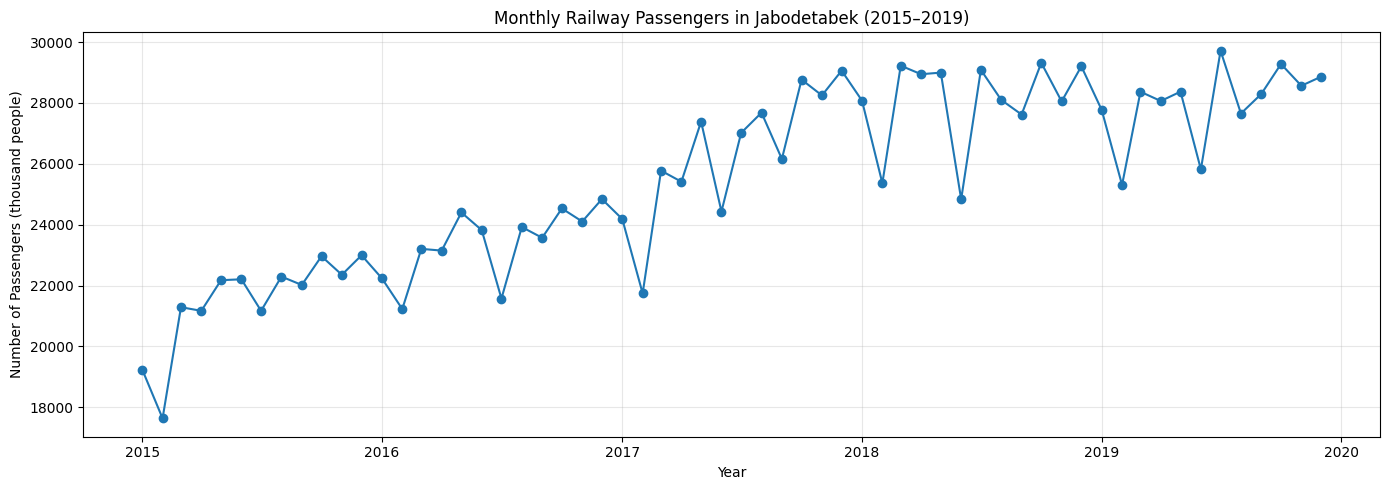

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    df_long["Tanggal"],
    df_long["Jumlah_Penumpang"],
    marker="o"
)

plt.title("Monthly Railway Passengers in Jabodetabek (2015–2019)")
plt.xlabel("Year")
plt.ylabel("Number of Passengers (thousand people)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
df_long["Jumlah_Penumpang"].describe()

,Jumlah_Penumpang
count,60.000000
mean,25446.966667
std,3046.851695
min,17640.000000
25%,22988.000000
50%,25386.500000
75%,28257.750000
max,29714.000000


In [12]:
yearly_avg = df_long.groupby("Tahun")["Jumlah_Penumpang"].mean()

yearly_avg

,Jumlah_Penumpang
Tahun,
2015,21460.916667
2016,23382.416667
2017,26321.166667
2018,28066.583333
2019,28003.750000


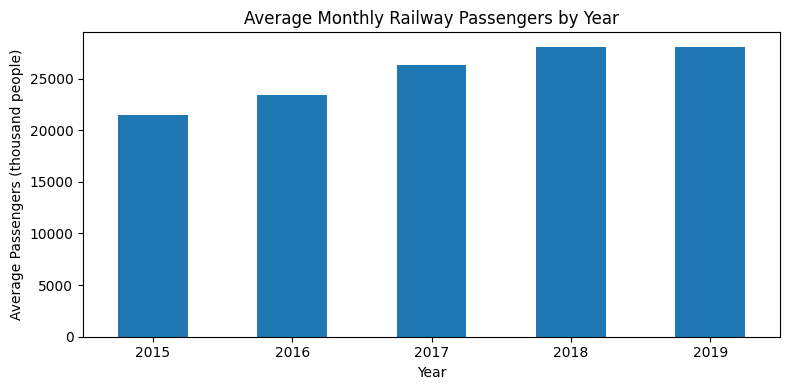

In [13]:
yearly_avg.plot(
    kind="bar",
    figsize=(8, 4),
    title="Average Monthly Railway Passengers by Year"
)

plt.xlabel("Year")
plt.ylabel("Average Passengers (thousand people)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5. Monthly Seasonality Analysis

Average passenger volume is calculated for each calendar month across the study period. This helps explore whether certain months tend to have relatively higher or lower passenger volumes.


In [14]:
# Rata-rata jumlah penumpang untuk setiap bulan
monthly_avg = (
    df_long.groupby("Bulan_Angka")["Jumlah_Penumpang"]
    .mean()
)

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_avg.index = month_names

monthly_avg

,Jumlah_Penumpang
Jan,24302.0
Feb,22255.8
Mar,25572.0
Apr,25347.0
May,26265.4
Jun,24221.8
Jul,25712.2
Aug,25929.2
Sep,25532.0
Oct,26971.4


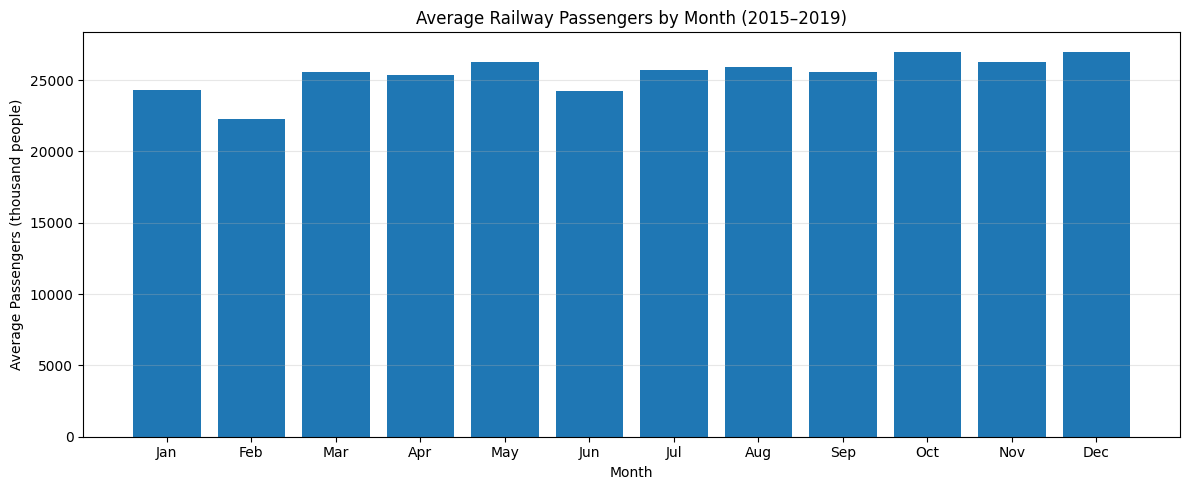

In [15]:
plt.figure(figsize=(12, 5))

plt.bar(monthly_avg.index, monthly_avg.values)

plt.title("Average Railway Passengers by Month (2015–2019)")
plt.xlabel("Month")
plt.ylabel("Average Passengers (thousand people)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 6. Time Series Decomposition

The monthly time series is decomposed into trend, seasonal, and residual components using an additive model with a 12-month seasonal period. This provides a visual examination of long-term movement and recurring yearly patterns.


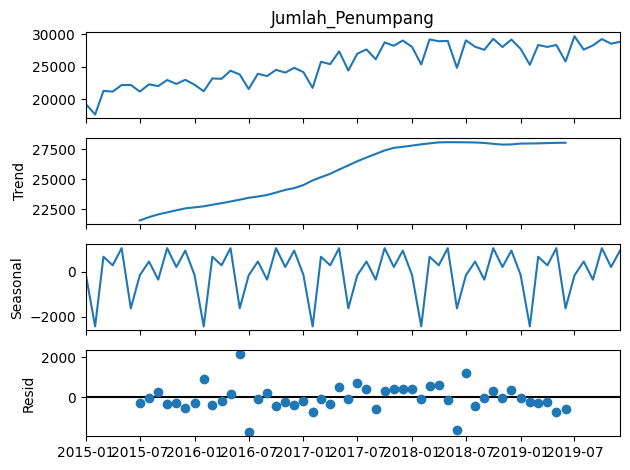

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = df_long.set_index("Tanggal")["Jumlah_Penumpang"]

decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=12
)

decomposition.plot()
plt.tight_layout()
plt.show()

### 7. Train-Test Split

The observations from 2015 to 2018 are used as training data, while 2019 is held out as test data. This allows the forecasting models to be evaluated against observations not used during model fitting.


In [17]:
# Siapkan time series dengan tanggal sebagai index
ts = df_long.set_index("Tanggal")["Jumlah_Penumpang"].sort_index()

# Training: 2015–2018
train = ts[ts.index.year <= 2018]

# Testing: 2019
test = ts[ts.index.year == 2019]

print("Training:", train.index.min(), "sampai", train.index.max())
print("Jumlah data training:", len(train))

print("\nTesting:", test.index.min(), "sampai", test.index.max())
print("Jumlah data testing:", len(test))

Training: 2015-01-01 00:00:00 sampai 2018-12-01 00:00:00
Jumlah data training: 48

Testing: 2019-01-01 00:00:00 sampai 2019-12-01 00:00:00
Jumlah data testing: 12


### 8. Seasonal Naive Forecast

A Seasonal Naive model is used as a baseline. Each month in 2019 is forecast using the observed passenger volume from the corresponding month in 2018.


In [18]:
# Seasonal Naive Forecast
# Prediksi 2019 menggunakan bulan yang sama pada 2018

forecast = train[train.index.year == 2018].copy()

forecast.index = forecast.index + pd.DateOffset(years=1)

forecast.name = "Forecast"

forecast

,Forecast
Tanggal,
2019-01-01,28075
2019-02-01,25362
2019-03-01,29223
2019-04-01,28942
2019-05-01,28995
2019-06-01,24833
2019-07-01,29086
2019-08-01,28098
2019-09-01,27618


In [19]:
comparison = pd.DataFrame({
    "Actual": test,
    "Forecast": forecast
})

comparison

,Actual,Forecast
Tanggal,,
2019-01-01,27768,28075
2019-02-01,25305,25362
2019-03-01,28366,29223
2019-04-01,28062,28942
2019-05-01,28369,28995
2019-06-01,25816,24833
2019-07-01,29714,29086
2019-08-01,27651,28098
2019-09-01,28293,27618


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    comparison["Actual"],
    comparison["Forecast"]
)

rmse = np.sqrt(mean_squared_error(
    comparison["Actual"],
    comparison["Forecast"]
))

mape = np.mean(
    np.abs(
        (comparison["Actual"] - comparison["Forecast"])
        / comparison["Actual"]
    )
) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 529.50
RMSE: 605.28
MAPE: 1.89%


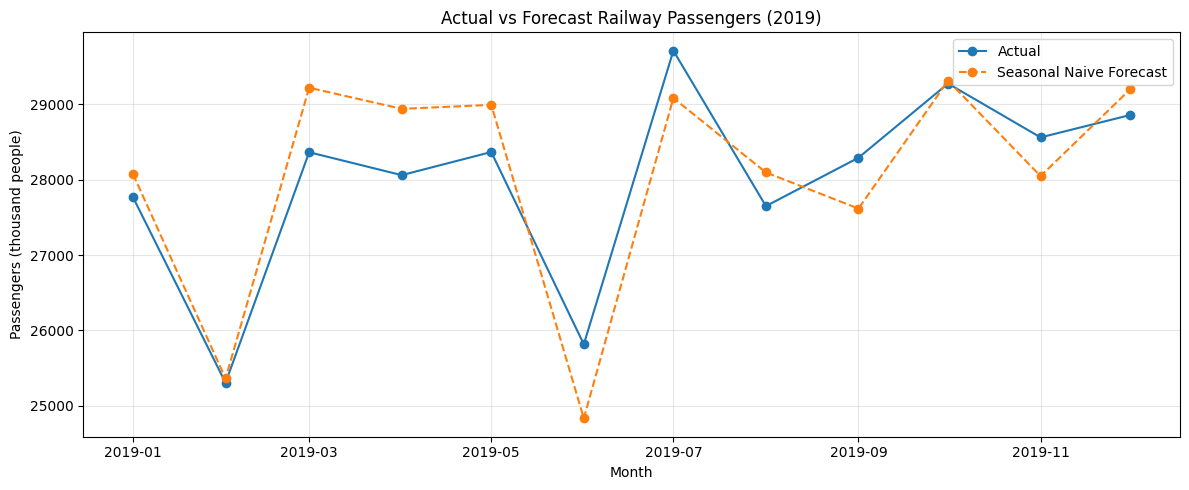

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(test.index, test, marker="o", label="Actual")
plt.plot(forecast.index, forecast, marker="o", linestyle="--",
         label="Seasonal Naive Forecast")

plt.title("Actual vs Forecast Railway Passengers (2019)")
plt.xlabel("Month")
plt.ylabel("Passengers (thousand people)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9. Holt-Winters Forecast

An additive Holt-Winters model is fitted to the training data with an additive trend and 12-month seasonality. The fitted model is used to forecast the 12 months of 2019.


In [22]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Model Holt-Winters dengan tren dan musiman
hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

# Prediksi 12 bulan tahun 2019
hw_forecast = hw_model.forecast(12)

hw_forecast

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,0
2019-01-01,28356.293717
2019-02-01,26416.878614
2019-03-01,29794.784720
2019-04-01,29590.367905
2019-05-01,30655.496556
2019-06-01,28747.981564
2019-07-01,29638.942544
2019-08-01,30428.602683
2019-09-01,29776.224519
2019-10-01,31322.252669


In [23]:
comparison["Holt_Winters"] = hw_forecast

comparison

,Actual,Forecast,Holt_Winters
Tanggal,,,
2019-01-01,27768,28075,28356.293717
2019-02-01,25305,25362,26416.878614
2019-03-01,28366,29223,29794.784720
2019-04-01,28062,28942,29590.367905
2019-05-01,28369,28995,30655.496556
2019-06-01,25816,24833,28747.981564
2019-07-01,29714,29086,29638.942544
2019-08-01,27651,28098,30428.602683
2019-09-01,28293,27618,29776.224519


### 10. Model Evaluation and Comparison

Forecasts are compared with the actual observations from 2019. MAE, RMSE, and MAPE are calculated to summarize prediction errors. A comparison chart is also used to visually inspect the differences between actual and forecast values.


In [24]:
hw_mae = mean_absolute_error(
    comparison["Actual"],
    comparison["Holt_Winters"]
)

hw_rmse = np.sqrt(mean_squared_error(
    comparison["Actual"],
    comparison["Holt_Winters"]
))

hw_mape = np.mean(
    np.abs(
        (comparison["Actual"] - comparison["Holt_Winters"])
        / comparison["Actual"]
    )
) * 100

print(f"Holt-Winters MAE: {hw_mae:.2f}")
print(f"Holt-Winters RMSE: {hw_rmse:.2f}")
print(f"Holt-Winters MAPE: {hw_mape:.2f}%")

Holt-Winters MAE: 1740.05
Holt-Winters RMSE: 1930.53
Holt-Winters MAPE: 6.25%


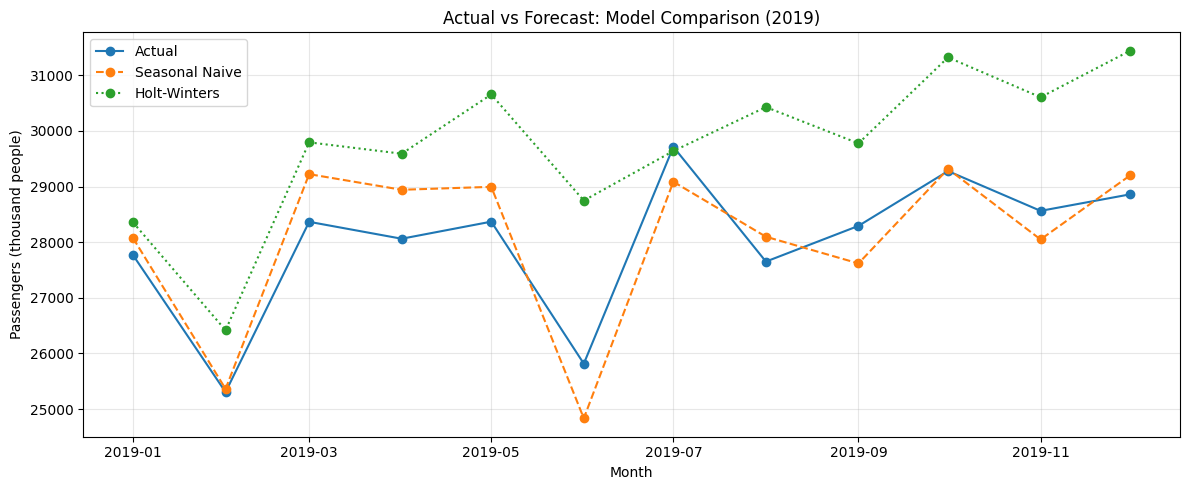

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(
    comparison.index,
    comparison["Actual"],
    marker="o",
    label="Actual"
)

plt.plot(
    comparison.index,
    comparison["Forecast"],
    marker="o",
    linestyle="--",
    label="Seasonal Naive"
)

plt.plot(
    comparison.index,
    comparison["Holt_Winters"],
    marker="o",
    linestyle=":",
    label="Holt-Winters"
)

plt.title("Actual vs Forecast: Model Comparison (2019)")
plt.xlabel("Month")
plt.ylabel("Passengers (thousand people)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
evaluation = pd.DataFrame({
    "Model": ["Seasonal Naive", "Holt-Winters"],
    "MAE": [529.50, 1740.05],
    "RMSE": [605.28, 1930.53],
    "MAPE (%)": [1.89, 6.25]
})

evaluation

,Model,MAE,RMSE,MAPE (%)
0,Seasonal Naive,529.50,605.28,1.89
1,Holt-Winters,1740.05,1930.53,6.25


## 11. Conclusion

The exploratory analysis shows an overall increase in monthly railway passenger volume during 2015–2019, with fluctuations across months. Time series decomposition also indicates recurring seasonal variation.

On the 2019 test period, the Seasonal Naive model achieved lower forecast errors than the additive Holt-Winters model across MAE, RMSE, and MAPE. This indicates that the Seasonal Naive forecasts were closer to actual observations for this particular test period.

The evaluation is limited to one 12-month test period, so the results should not be assumed to generalize to other periods.
